In [48]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.misc import derivative

/tmp/ipykernel_253298/1402121171.py:69: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 1e6)


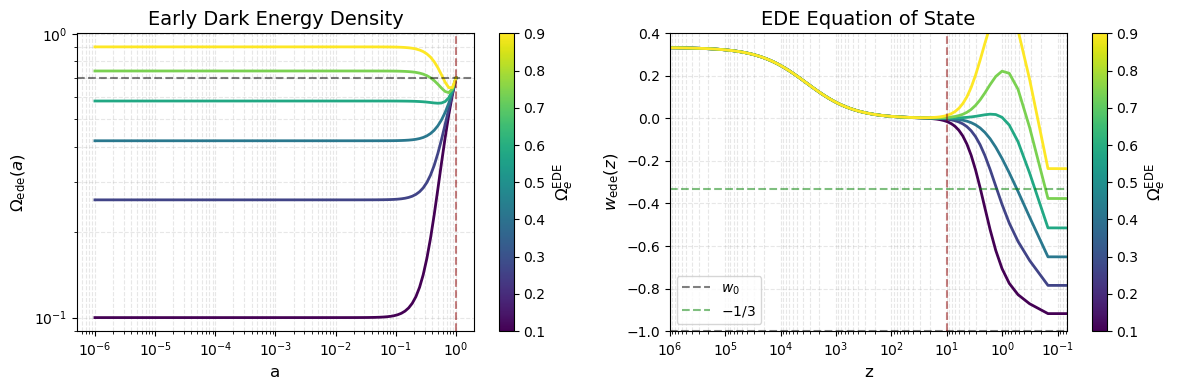

In [49]:
import numpy as np
import matplotlib.pyplot as plt

# Constants and parameters
Omega_ede0 = 0.7       
Omega_eEDE_values = np.linspace(0.1, 0.9, 6)  
Omega_m0 = 0.3         
w0 = -1.0          
a_eq = 1/3400       

a = np.logspace(0,-6, 100)  
z = (1/a) -1.
         


def Omega_ede(a, Omega_eEDE):
    term1 = (Omega_ede0 - (Omega_eEDE * (1. - a**(-3.*w0))))
    term2 = (Omega_ede0 + (Omega_m0 * a**(3.*w0)))
    term3 = Omega_eEDE * (1 - a**(-3.*w0))
    return (term1/term2) + term3


def dlnOmega_dlna(a, Omega_eEDE):
    term1 = -3 * w0 *Omega_eEDE * a**(- 3 * w0) * (Omega_ede0  + Omega_m0 *a**(3*w0))
    term2 = - (Omega_ede0  - Omega_eEDE*(1-a**(-3*w0)))*3*w0*Omega_m0*a**(3*w0)
    term3 = ((Omega_ede0 + (Omega_m0 * a**(3.*w0))))**2.
    term4 = 3*w0*Omega_eEDE * a**(-3 *w0)
    return ((term1 + term2)/term3 + term4)/Omega_ede(a, Omega_eEDE)


def w_ede(a, Omega_eEDE):
    term1 = - dlnOmega_dlna(a, Omega_eEDE)/(3.*(1. - Omega_ede(a, Omega_eEDE))) 
    term2 = a_eq/(3.*(a + a_eq))
    return term1 + term2

# Create plot
fig = plt.figure(figsize=(12, 4))

# Color map for different Omega_eEDE values
cmap = plt.cm.viridis
norm = plt.Normalize(vmin=min(Omega_eEDE_values), vmax=max(Omega_eEDE_values))

# Plot Omega_ede(z) for all values
ax1 = plt.subplot(1, 2, 1)
for i, Omega_eEDE in enumerate(Omega_eEDE_values):
    Omega_ede_vals = np.array([Omega_ede(ai, Omega_eEDE) for ai in a])
    plt.loglog(a, Omega_ede_vals, '-', lw=2, color=cmap(norm(Omega_eEDE)))

plt.axhline(Omega_ede0, color='k', linestyle='--', alpha=0.5)
plt.axvline(x=1, color='darkred', linestyle='--', alpha=0.5)
plt.xlabel('a', fontsize=12)
plt.ylabel(r'$\Omega_{\rm ede}(a)$', fontsize=12)
plt.title('Early Dark Energy Density', fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.3)

# Add colorbar for first subplot
cbar1 = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax1)
cbar1.set_label(r'$\Omega_e^{\rm EDE}$', fontsize=12)

# Plot w_ede(z) for all values
ax2 = plt.subplot(1, 2, 2)
for i, Omega_eEDE in enumerate(Omega_eEDE_values):
    w_ede_vals = np.array([w_ede(ai, Omega_eEDE) for ai in a])
    plt.semilogx(z, w_ede_vals, '-', lw=2, color=cmap(norm(Omega_eEDE)))

plt.axhline(w0, color='k', linestyle='--', alpha=0.5, label='$w_0$')
plt.axhline(-1/3, color='g', linestyle='--', alpha=0.5, label='$-1/3$')
plt.axvline(x=10, color='darkred', linestyle='--', alpha=0.5)
plt.xlim(0, 1e6)  
plt.ylim(-1.0, 0.4)
plt.gca().invert_xaxis()
plt.xlabel('z', fontsize=12)
plt.ylabel(r'$w_{\rm ede}(z)$', fontsize=12)
plt.title('EDE Equation of State', fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend(fontsize=10)

# Add colorbar for second subplot
cbar2 = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax2)
cbar2.set_label(r'$\Omega_e^{\rm EDE}$', fontsize=12)

plt.tight_layout()
plt.show()

### Using 
$$
\rho_{de} = \rho_{cri} \Omega_{de} = \Omega_{de} \frac{3 H^2}{8 \pi G}
$$
### and the Hubble parameter given by 
$$
\frac{H(a)^2}{H_0^2} = \frac{\Omega_{m,0}a^{-3} + \Omega_{r,0}a^{-4}}{1-\Omega_{de}} 
$$
### first, we need to find the Hubble parameter

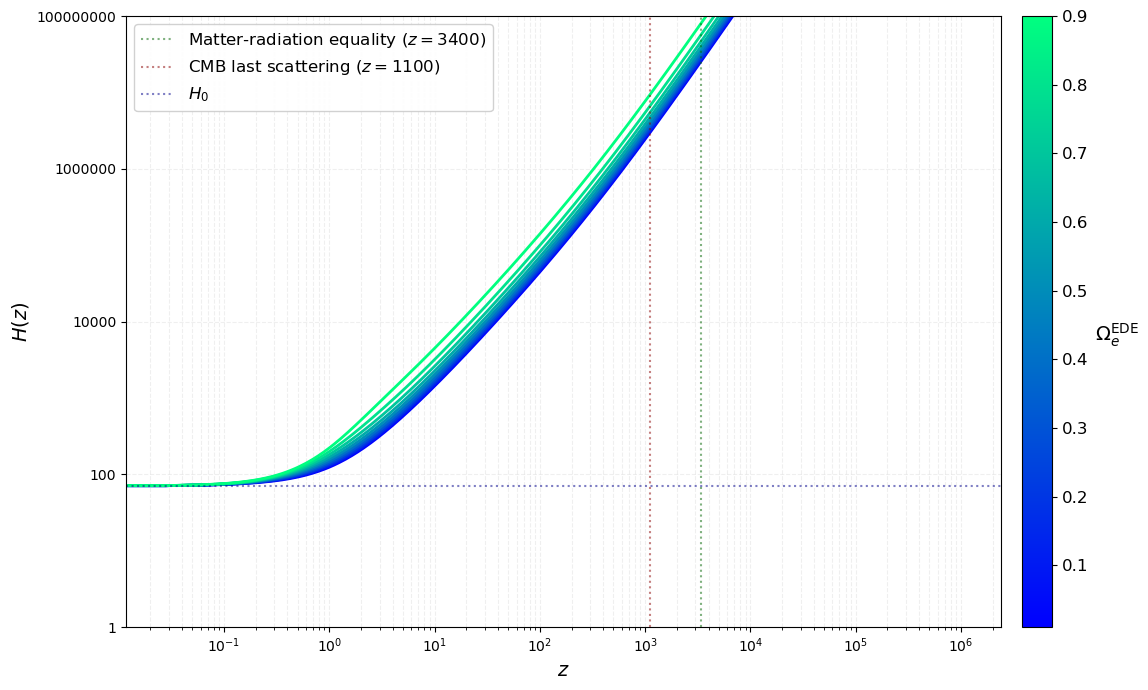

In [45]:
#################################
#                               #
#       HUBBLE PARAMETER        # 
#                               # 
#################################


import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# Cosmological parameters
Omega_ede0 = 0.7          # Present EDE density
Omega_m0 = 0.3            # Matter density
Omega_r0 = 9e-4           # Radiation density
w0 = -1.0                 # EDE equation of state parameter
H0 = 70                   # Hubble constant [km/s/Mpc]

 


# Early EDE values 
Omega_eEDE_values = np.linspace(0.01, 0.9, 10) 

def Omega_ede(a, Omega_eEDE):
    term1 = (Omega_ede0 - (Omega_eEDE * (1. - a**(-3.*w0))))
    term2 = (Omega_ede0 + (Omega_m0 * a**(3.*w0)))
    term3 = Omega_eEDE * (1 - a**(-3.*w0))
    return (term1/term2) + term3



def hubble_parameter(a, Omega_eEDE):
    return H0*np.sqrt((Omega_m0*a**(-3) + Omega_r0*a**(-4))/(1-Omega_ede(a, Omega_eEDE)))

# Create figure with improved layout
fig, ax = plt.subplots(figsize=(12, 7))

# Set up colormap and normalization
cmap = plt.cm.winter
norm = Normalize(vmin=min(Omega_eEDE_values), vmax=max(Omega_eEDE_values))

# Plot Hubble parameter for each Omega_eEDE value
for Omega_eEDE in Omega_eEDE_values:
    H = hubble_parameter(a, Omega_eEDE)
    plt.plot(z, H, '-', lw=2, color=cmap(norm(Omega_eEDE)))

# Highlight key cosmological epochs
plt.axvline(x=3400, color='darkgreen', ls=':', alpha=0.5, label='Matter-radiation equality ($z=3400$)')
plt.axvline(x=1100, color='darkred', ls=':', alpha=0.5, label='CMB last scattering ($z=1100$)')
plt.axhline(y=70, color='darkblue', ls=':', alpha=0.5, label='$H_0$')

# Add colorbar
cbar = plt.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax, 
                    orientation='vertical', pad=0.02)
cbar.set_label(r'$\Omega_e^{\mathrm{EDE}}$', fontsize=14, rotation=0, labelpad=20)
cbar.ax.tick_params(labelsize=12)

# Formatting
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('$z$', fontsize=14)
ax.set_ylabel('$H(z)$', fontsize=14)

# Set axis limits to ensure positive values for log scale
ax.set_ylim(1, 1e8)  # Adjusted to show full range of H(z)

# Custom log-formatting for axes
ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'{y:.0f}'))

plt.grid(True, which="both", ls="--", alpha=0.2)
plt.legend(fontsize=12, framealpha=0.9)

plt.tight_layout()
plt.show()



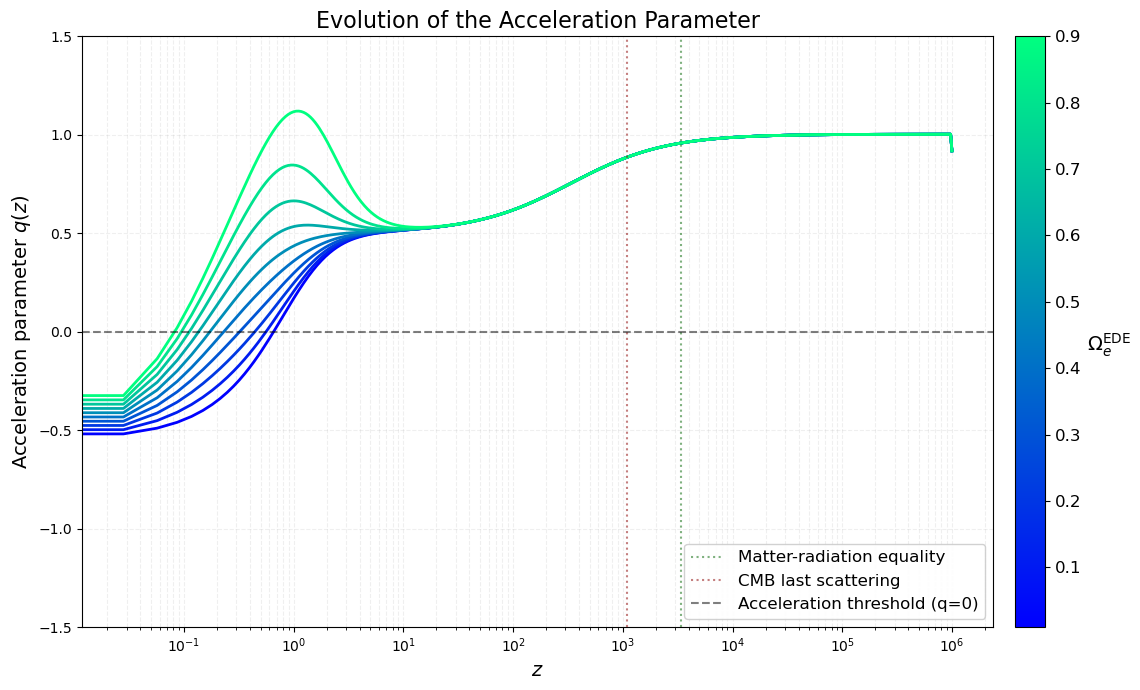

In [46]:
def acceleration_parameter(a, Omega_eEDE):
    # Compute q = -1 - dH/dt / H^2
    # Using dH/dt = aH dH/da and H = H(a)
    H = hubble_parameter(a, Omega_eEDE)
    
    # Numerical derivative of H with respect to a
    dHda = np.gradient(H, a)
    dHdt = a * H * dHda
    
    q = -1 - dHdt / H**2
    return q

# Create figure
fig, ax = plt.subplots(figsize=(12, 7))
cmap = plt.cm.winter
norm = Normalize(vmin=min(Omega_eEDE_values), vmax=max(Omega_eEDE_values))

# Plot acceleration parameter for each Omega_eEDE value
for Omega_eEDE in Omega_eEDE_values:
    q = acceleration_parameter(a, Omega_eEDE)
    plt.plot(z, q, '-', lw=2, color=cmap(norm(Omega_eEDE)))

# Highlight key epochs and transitions
plt.axvline(x=3400, color='darkgreen', ls=':', alpha=0.5, label='Matter-radiation equality')
plt.axvline(x=1100, color='darkred', ls=':', alpha=0.5, label='CMB last scattering')
plt.axhline(y=0, color='k', ls='--', alpha=0.5, label='Acceleration threshold (q=0)')

# Formatting
ax.set_xscale('log')
ax.set_xlabel('$z$', fontsize=14)
ax.set_ylabel('Acceleration parameter $q(z)$', fontsize=14)
ax.set_title('Evolution of the Acceleration Parameter', fontsize=16)

# Set reasonable y-limits to see transition
ax.set_ylim(-1.5, 1.5)

# Add colorbar
cbar = plt.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax, 
                    orientation='vertical', pad=0.02)
cbar.set_label(r'$\Omega_e^{\mathrm{EDE}}$', fontsize=14, rotation=0, labelpad=20)
cbar.ax.tick_params(labelsize=12)

plt.grid(True, which="both", ls="--", alpha=0.2)
plt.legend(fontsize=12, framealpha=0.9, loc='lower right')

plt.tight_layout()
plt.show()

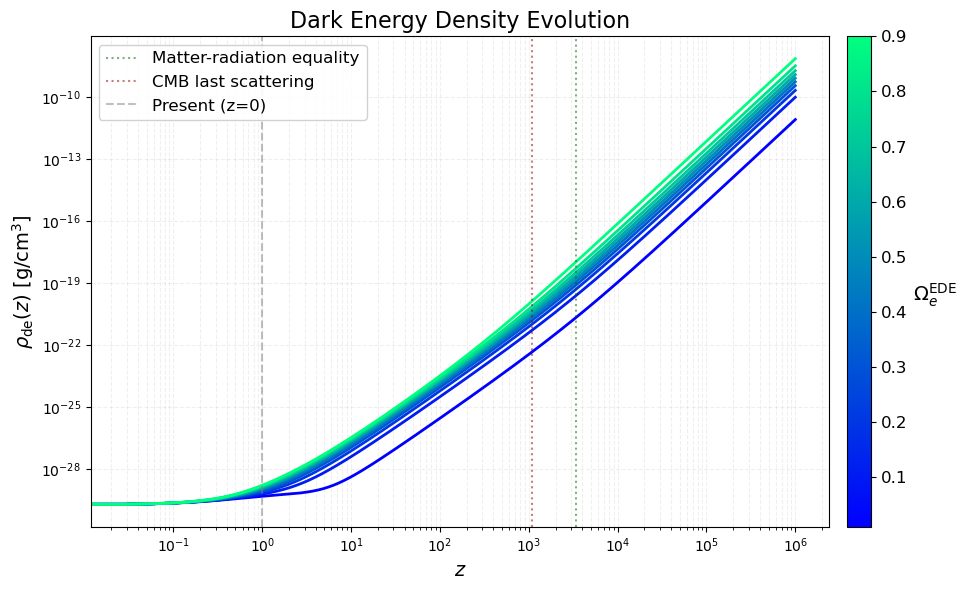

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from astropy.constants import c, G, M_sun, pc
from astropy import units as u

H0 = 67.66  # km/s/Mpc
Omega_m0 = 0.311  # Matter density parameter
Omega_r0 = 9.18e-5  # Radiation density parameter
Omega_ede0 = 1 - Omega_m0 - Omega_r0  # Dark energy density parameter
w0 = -1  # Dark energy equation of state

# Convert H0 to SI units (1/s)
H0_SI = H0 * u.km / u.s / u.Mpc
H0_SI = H0_SI.to(1/u.s)


a = np.logspace(0, -6, 500)
z = 1/a - 1

Omega_eEDE_values = np.linspace(0.01, 0.9, 10) 

def Omega_ede(a, Omega_eEDE):
    term1 = (Omega_ede0 - (Omega_eEDE * (1. - a**(-3.*w0))))
    term2 = (Omega_ede0 + (Omega_m0 * a**(3.*w0)))
    term3 = Omega_eEDE * (1 - a**(-3.*w0))
    return (term1/term2) + term3

def hubble_parameter(a, Omega_eEDE):
    return H0_SI.value * np.sqrt(Omega_m0*a**(-3) + Omega_r0*a**(-4)/(1-Omega_ede(a, Omega_eEDE)))

def energy_density(a, Omega_eEDE):
    H = hubble_parameter(a, Omega_eEDE)  # Now in 1/s
    rho_crit = 3 * H**2 / (8 * np.pi * G.value)  # kg/m³
    rho_de = rho_crit * Omega_ede(a, Omega_eEDE)
    
    # Convert to g/cm³ (instead of GeV/cm³)
    rho_de = rho_de * (u.kg/u.m**3)
    rho_de = rho_de.to(u.g/u.cm**3)  
    return rho_de.value


fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.cm.winter
norm = Normalize(vmin=min(Omega_eEDE_values), vmax=max(Omega_eEDE_values))

for Omega_eEDE in Omega_eEDE_values:
    rho = energy_density(a, Omega_eEDE)
    ax.plot(z, rho, '-', lw=2, color=cmap(norm(Omega_eEDE)))


ax.axvline(x=3400, color='darkgreen', ls=':', alpha=0.5, label='Matter-radiation equality')
ax.axvline(x=1100, color='darkred', ls=':', alpha=0.5, label='CMB last scattering')
ax.axvline(x=1, color='gray', ls='--', alpha=0.5, label='Present (z=0)')


ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, which="both", ls="--", alpha=0.2)
ax.legend(fontsize=12, framealpha=0.9)


ax.set_ylabel(r'$\rho_{\rm de}(z)$ [g/cm$^3$]', fontsize=14)
ax.set_title('Dark Energy Density Evolution', fontsize=16)
ax.set_xlabel('$z$', fontsize=14)


cbar = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax, orientation='vertical', pad=0.02)
cbar.set_label(r'$\Omega_e^{\mathrm{EDE}}$', fontsize=14, rotation=0, labelpad=20)
cbar.ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()